# BeeMonitor Parameter Tuning - Reduce False Blob Detections

This notebook helps you tune detection parameters to reduce false positives (too many blobs).

## Problem:
Getting too many blob detections that create noisy/fragmented tracks

## Solution:
1. Increase blob detection thresholds (min_area, min_solidity)
2. Add noise filtering
3. Use multi-modal detection (SIFT + YOLO)
4. Properly initialize background
5. Focus on ROI (bee hotel region only)

## Setup

In [1]:
import os
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, HTML
from tqdm.notebook import tqdm

from beemonitor import BeeMonitor
from beemonitor.core.config import Config

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✓ Imports successful")

✓ Imports successful


## Configuration

In [2]:
# Input/Output paths
VIDEO_FILE = "/Users/edwardamoah/Documents/GitHub/BeeMonitor/videos/mendels_2025/short_videos/mendels_2024-04-30_09_30_01.mp4"
OUTPUT_FOLDER = "/Users/edwardamoah/Documents/GitHub/BeeMonitor/videos/mendels_2025/poster_videos"

# Ensure output folder exists
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print(f"Video: {VIDEO_FILE}")
print(f"Output: {OUTPUT_FOLDER}")
print(f"Video exists: {os.path.exists(VIDEO_FILE)}")

Video: /Users/edwardamoah/Documents/GitHub/BeeMonitor/videos/mendels_2025/short_videos/mendels_2024-04-30_09_30_01.mp4
Output: /Users/edwardamoah/Documents/GitHub/BeeMonitor/videos/mendels_2025/poster_videos
Video exists: True


## Step 1: Check Current Configuration

In [3]:
# Load default config to see what we're working with
config_default = Config.default()

print("="*60)
print("CURRENT DEFAULT CONFIGURATION")
print("="*60)

print("\n📊 Blob Detection Parameters:")
print(f"  min_area: {config_default.detection.min_area}")
print(f"  min_solidity: {config_default.detection.min_solidity}")
if hasattr(config_default.detection, 'max_area'):
    print(f"  max_area: {config_default.detection.max_area}")
else:
    print(f"  max_area: Not set (will detect huge blobs!)")

print("\n🔧 Morphological Operations:")
if hasattr(config_default.detection, 'erosion_kernel_size'):
    print(f"  erosion_kernel_size: {config_default.detection.erosion_kernel_size}")
if hasattr(config_default.detection, 'dilation_kernel_size'):
    print(f"  dilation_kernel_size: {config_default.detection.dilation_kernel_size}")

print("\n🎯 Detection Mode:")
if hasattr(config_default.detection, 'detection_mode'):
    print(f"  mode: {config_default.detection.detection_mode}")
else:
    print(f"  mode: Not specified (probably FGBG_ONLY)")

print("\n🧹 Noise Filtering:")
if hasattr(config_default.detection, 'use_noise_filter'):
    print(f"  use_noise_filter: {config_default.detection.use_noise_filter}")
else:
    print(f"  use_noise_filter: Not available")

print("\n🎬 Tracking Parameters:")
print(f"  max_age: {config_default.tracking.max_age}")
print(f"  initial_distance_threshold: {config_default.tracking.initial_distance_threshold}")

print("\n" + "="*60)

CURRENT DEFAULT CONFIGURATION

📊 Blob Detection Parameters:


AttributeError: 'Config' object has no attribute 'detection'

## Step 2: Load Video and Inspect First Frame

Video Properties:
  Resolution: 1280x720
  FPS: 29.97002997002997
  Total frames: 224
  Duration: 7.5s


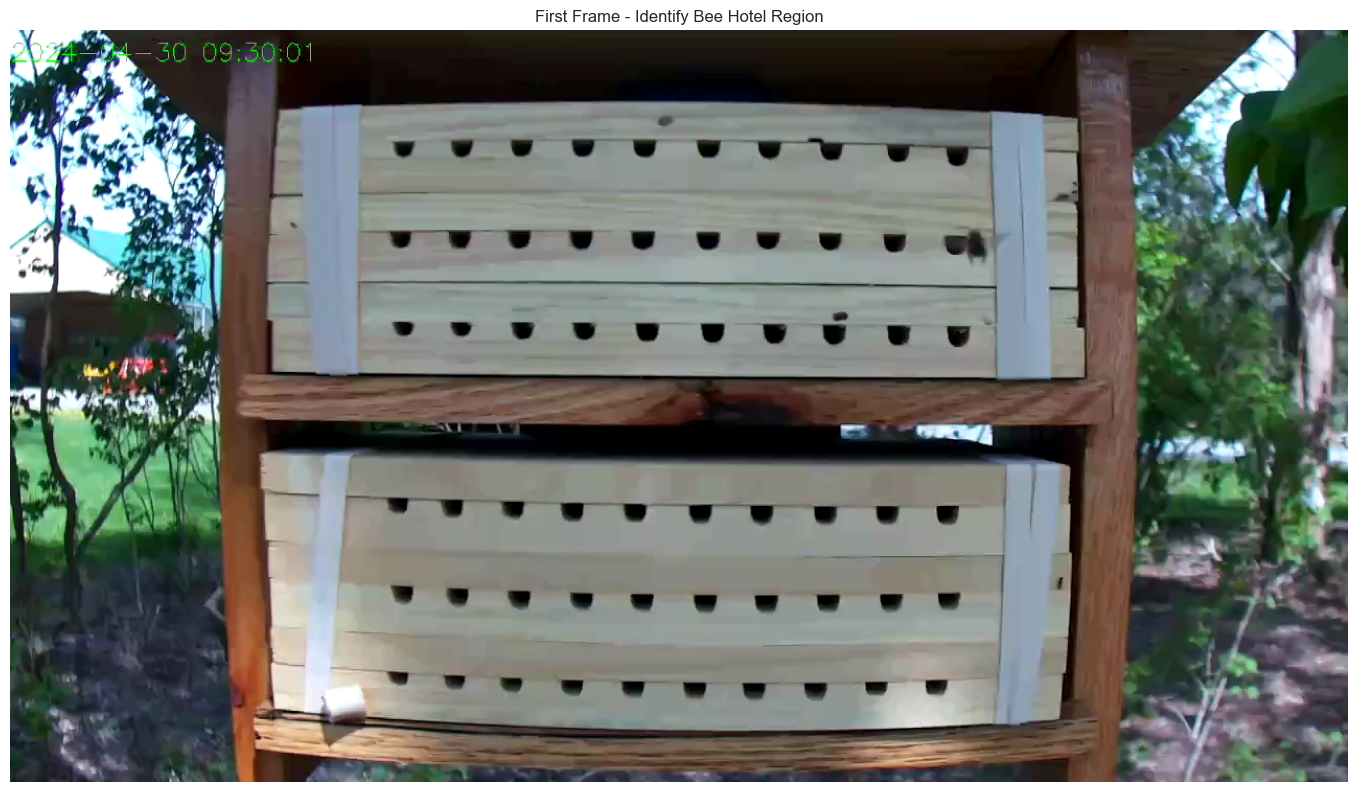


✓ Video loaded successfully


In [4]:
# Load video
cap = cv2.VideoCapture(VIDEO_FILE)
if not cap.isOpened():
    raise ValueError(f"Cannot open video: {VIDEO_FILE}")

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Video Properties:")
print(f"  Resolution: {width}x{height}")
print(f"  FPS: {fps}")
print(f"  Total frames: {total_frames}")
print(f"  Duration: {total_frames/fps:.1f}s")

# Read first frame
ret, first_frame = cap.read()
cap.release()

if not ret:
    raise ValueError("Failed to read first frame")

# Display first frame
plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
plt.title('First Frame - Identify Bee Hotel Region')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n✓ Video loaded successfully")

## Step 3: Define ROI (Region of Interest)

**IMPORTANT**: Only process the bee hotel region to avoid false positives from background motion.

Update these coordinates based on your video:

⚠ No ROI defined - will process full frame
  Tip: Define ROI to focus on bee hotel and reduce false positives


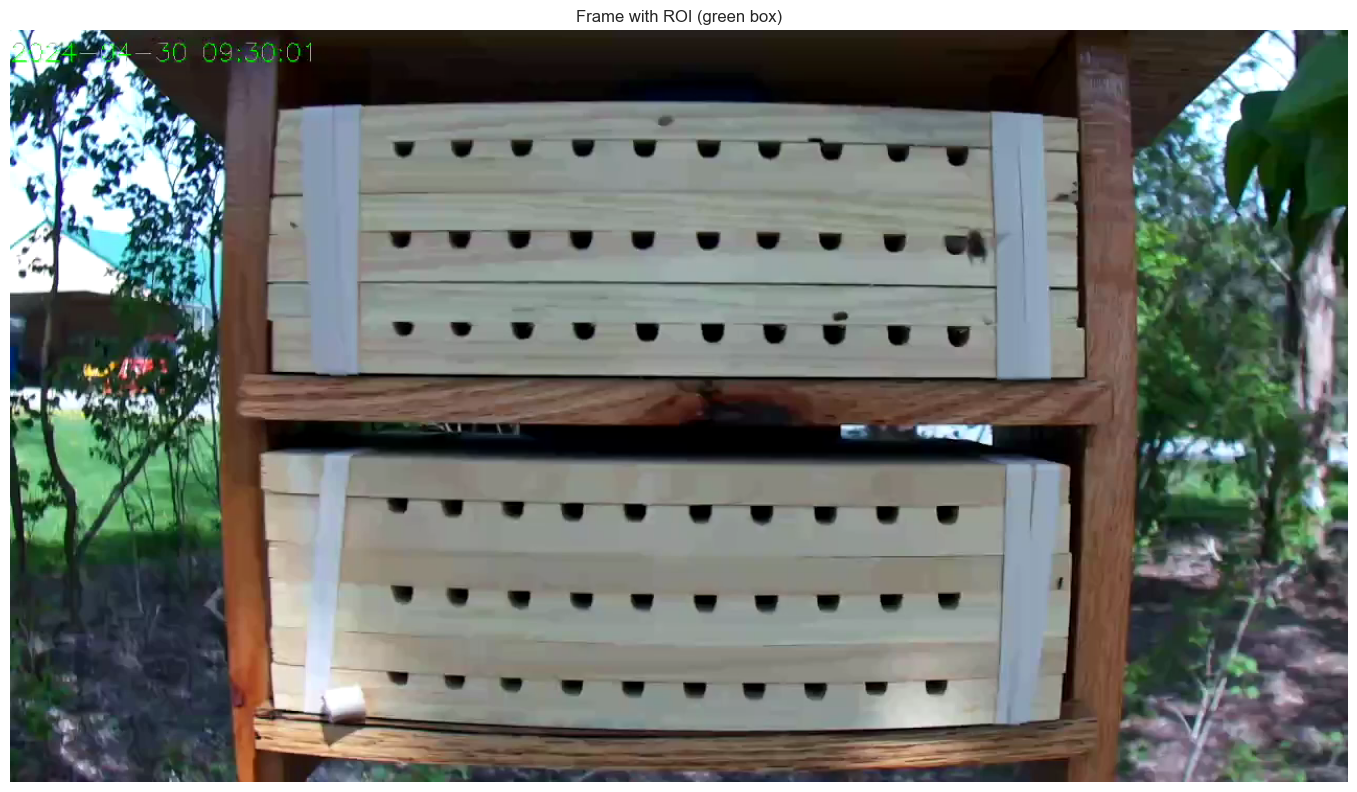

In [5]:
# Define ROI - UPDATE THESE COORDINATES
# Format: (x1, y1, x2, y2)
# Look at the frame above and estimate where the bee hotel is

ROI = None  # Set to None to use full frame, or (x1, y1, x2, y2) for specific region

# Example ROI (adjust based on your video):
# ROI = (300, 200, 1000, 800)  # Left hotel region

# Visualize ROI
frame_with_roi = first_frame.copy()
if ROI is not None:
    x1, y1, x2, y2 = ROI
    cv2.rectangle(frame_with_roi, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(frame_with_roi, "ROI", (x1+10, y1+40),
               cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3)
    
    roi_width = x2 - x1
    roi_height = y2 - y1
    print(f"✓ ROI defined:")
    print(f"  Position: ({x1}, {y1}) to ({x2}, {y2})")
    print(f"  Size: {roi_width}x{roi_height} pixels")
else:
    print("⚠ No ROI defined - will process full frame")
    print("  Tip: Define ROI to focus on bee hotel and reduce false positives")

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(frame_with_roi, cv2.COLOR_BGR2RGB))
plt.title('Frame with ROI (green box)')
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 4: Test Detection with Different Parameters

We'll test blob detection on a sample frame with different parameter sets to see the effect.

In [6]:
def test_blob_detection(frame, min_area, min_solidity, max_area=10000):
    """Test blob detection with given parameters."""
    from beemonitor.detection import BlobDetector
    
    # Create detector with test parameters
    detector = BlobDetector(
        min_area=min_area,
        min_solidity=min_solidity
    )
    
    # Initialize background with first 50 frames
    detector.initialize_from_video(
        video_path=VIDEO_FILE,
        num_frames=50,
        start_frame=0
    )
    
    # Detect on test frame
    detections = detector.detect(frame)
    
    # Filter by max_area
    detections = [d for d in detections if (d.bbox[2]-d.bbox[0])*(d.bbox[3]-d.bbox[1]) <= max_area]
    
    # Draw detections
    viz = frame.copy()
    for det in detections:
        x1, y1, x2, y2 = [int(c) for c in det.bbox]
        cv2.rectangle(viz, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    return detections, viz

# Test frame (frame 100 - should have some bee activity)
cap = cv2.VideoCapture(VIDEO_FILE)
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, test_frame = cap.read()
cap.release()

if not ret:
    test_frame = first_frame
    print("Using first frame for testing")
else:
    print("Using frame 100 for testing")

print("\nTesting different parameter sets...")
print("This will take a minute...\n")

Using frame 100 for testing

Testing different parameter sets...
This will take a minute...



Testing: Very Sensitive (Too many FP)...
Testing: Default (Typical)...
Testing: Conservative (Recommended)...
Testing: Very Conservative...


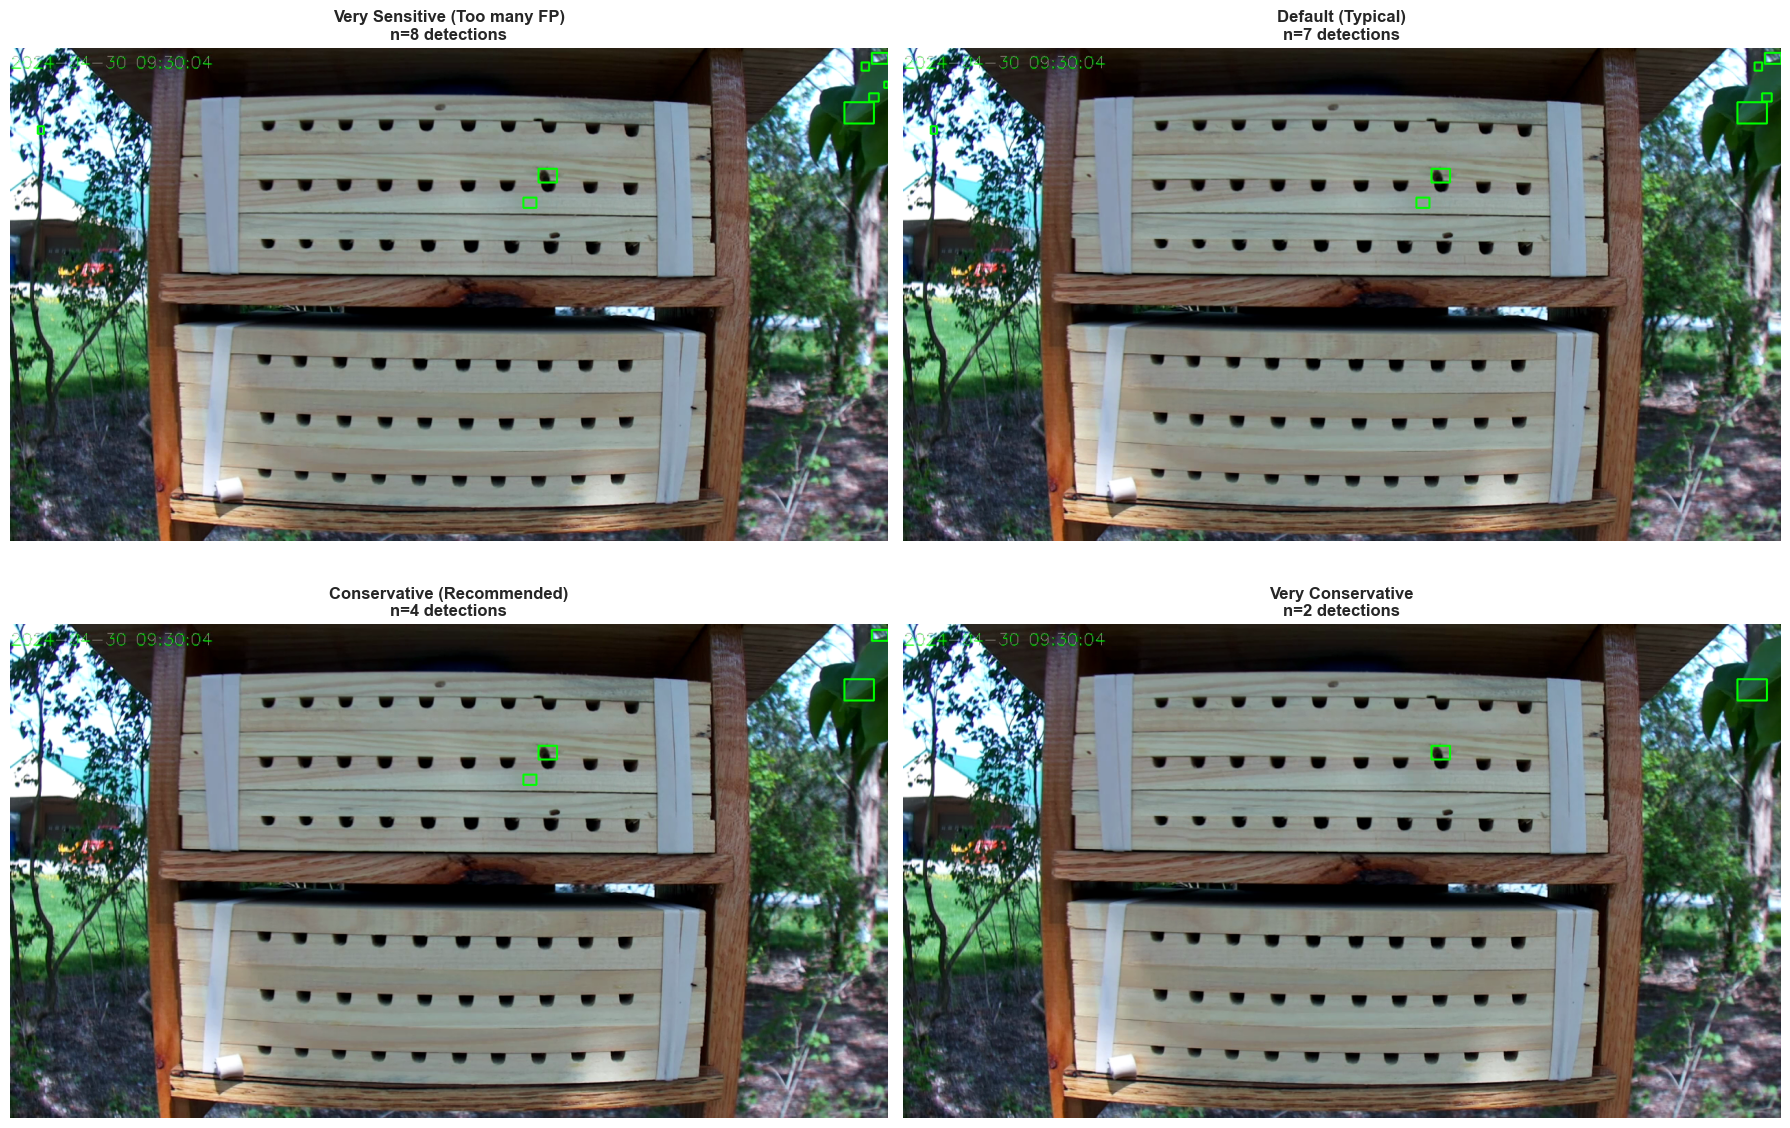


DETECTION COMPARISON


,Config,min_area,min_solidity,max_area,Detections
0,Very Sensitive (Too many FP),30,0.3,10000,8
1,Default (Typical),50,0.5,10000,7
2,Conservative (Recommended),120,0.7,4000,4
3,Very Conservative,200,0.8,3000,2



💡 Choose configuration with fewest false positives while still detecting real bees


In [7]:
# Test different parameter combinations
test_configs = [
    {"name": "Very Sensitive (Too many FP)", "min_area": 30, "min_solidity": 0.3, "max_area": 10000},
    {"name": "Default (Typical)", "min_area": 50, "min_solidity": 0.5, "max_area": 10000},
    {"name": "Conservative (Recommended)", "min_area": 120, "min_solidity": 0.7, "max_area": 4000},
    {"name": "Very Conservative", "min_area": 200, "min_solidity": 0.8, "max_area": 3000},
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

results_summary = []

for idx, cfg in enumerate(test_configs):
    print(f"Testing: {cfg['name']}...")
    
    dets, viz = test_blob_detection(
        test_frame,
        min_area=cfg['min_area'],
        min_solidity=cfg['min_solidity'],
        max_area=cfg['max_area']
    )
    
    results_summary.append({
        'Config': cfg['name'],
        'min_area': cfg['min_area'],
        'min_solidity': cfg['min_solidity'],
        'max_area': cfg['max_area'],
        'Detections': len(dets)
    })
    
    axes[idx].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
    axes[idx].set_title(f"{cfg['name']}\nn={len(dets)} detections", fontsize=12, weight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Show summary table
print("\n" + "="*80)
print("DETECTION COMPARISON")
print("="*80)
results_df = pd.DataFrame(results_summary)
display(results_df)
print("\n💡 Choose configuration with fewest false positives while still detecting real bees")

## Step 5: Create Optimized Configuration

Based on the tests above, create your optimized configuration:

In [8]:
# Create optimized configuration
config = Config.default()

print("Creating optimized configuration...\n")

# ════════════════════════════════════════════════════════════════════
# BLOB DETECTION PARAMETERS (Tune these to reduce false positives)
# ════════════════════════════════════════════════════════════════════

# Minimum blob area (increase to reject small noise)
config.detection.min_area = 120.0  # Default: 50, Recommended: 100-150

# Minimum solidity (increase to reject irregular shapes)
config.detection.min_solidity = 0.7  # Default: 0.5, Recommended: 0.65-0.8

# Maximum blob area (add to reject huge background motion)
if hasattr(config.detection, 'max_area'):
    config.detection.max_area = 4000.0  # Recommended: 3000-5000

# ════════════════════════════════════════════════════════════════════
# MORPHOLOGICAL OPERATIONS (Reduce noise)
# ════════════════════════════════════════════════════════════════════

if hasattr(config.detection, 'erosion_kernel_size'):
    config.detection.erosion_kernel_size = 3  # Increase to remove noise

if hasattr(config.detection, 'dilation_kernel_size'):
    config.detection.dilation_kernel_size = 5  # Adjust to merge close blobs

# ════════════════════════════════════════════════════════════════════
# DETECTION MODE (Multi-modal is more robust)
# ════════════════════════════════════════════════════════════════════

if hasattr(config.detection, 'detection_mode'):
    # Options: 'fgbg', 'sift', 'yolo', 'fgbg_sift', 'fgbg_yolo', 'fgbg_sift_yolo'
    config.detection.detection_mode = 'fgbg_sift_yolo'  # Most comprehensive

# ════════════════════════════════════════════════════════════════════
# NOISE FILTERING (If available)
# ════════════════════════════════════════════════════════════════════

if hasattr(config.detection, 'use_noise_filter'):
    config.detection.use_noise_filter = False  # Set True if you have trained CNN
    
if hasattr(config.detection, 'noise_filter_threshold'):
    config.detection.noise_filter_threshold = 0.9  # Conservative threshold

# ════════════════════════════════════════════════════════════════════
# YOLO PARAMETERS (If using YOLO detection)
# ════════════════════════════════════════════════════════════════════

if hasattr(config.detection, 'yolo_interval'):
    config.detection.yolo_interval = 10  # Confirm detections every N frames

if hasattr(config.detection, 'yolo_conf_threshold'):
    config.detection.yolo_conf_threshold = 0.3  # YOLO confidence threshold

# ════════════════════════════════════════════════════════════════════
# TRACKING PARAMETERS
# ════════════════════════════════════════════════════════════════════

config.tracking.max_age = 40  # How long to keep lost tracks (frames)
config.tracking.initial_distance_threshold = 50.0  # Match distance threshold

# ════════════════════════════════════════════════════════════════════
# BACKGROUND INITIALIZATION
# ════════════════════════════════════════════════════════════════════

if hasattr(config.detection, 'background_init_frames'):
    config.detection.background_init_frames = 100  # More frames = better background

# Print final configuration
print("✓ Optimized Configuration:")
print("\n📊 Blob Detection:")
print(f"  min_area: {config.detection.min_area}")
print(f"  min_solidity: {config.detection.min_solidity}")
if hasattr(config.detection, 'max_area'):
    print(f"  max_area: {config.detection.max_area}")

print("\n🎯 Detection Mode:")
if hasattr(config.detection, 'detection_mode'):
    print(f"  mode: {config.detection.detection_mode}")

print("\n🎬 Tracking:")
print(f"  max_age: {config.tracking.max_age}")
print(f"  distance_threshold: {config.tracking.initial_distance_threshold}")

print("\n" + "="*60)

Creating optimized configuration...



AttributeError: 'Config' object has no attribute 'detection'

## Step 6: Run Analysis with Optimized Configuration

In [9]:
# Create BeeMonitor with optimized config
monitor = BeeMonitor(config=config)

print("Starting video analysis...")
print(f"Video: {VIDEO_FILE}")
print(f"Output: {OUTPUT_FOLDER}")
if ROI is not None:
    print(f"ROI: {ROI}")
print("\nThis may take several minutes...\n")

# Run analysis
result = monitor.analyze_video(
    VIDEO_FILE,
    visualize=True,
    output_folder=OUTPUT_FOLDER,
    roi=ROI  # Use ROI if defined
)

print("\n✓ Analysis complete!")

Starting video analysis...
Video: /Users/edwardamoah/Documents/GitHub/BeeMonitor/videos/mendels_2025/short_videos/mendels_2024-04-30_09_30_01.mp4
Output: /Users/edwardamoah/Documents/GitHub/BeeMonitor/videos/mendels_2025/poster_videos

This may take several minutes...



TypeError: BeeMonitor.analyze_video() got an unexpected keyword argument 'roi'

## Step 7: Analyze Results

In [10]:
# Save results to CSV
output_csv = os.path.join(OUTPUT_FOLDER, 'tracking_results.csv')
result.to_csv(output_csv)
print(f"✓ Results saved to: {output_csv}")

# Display sample results
print("\nSample tracking results:")
display(result.head(20))

# Basic statistics
print("\n" + "="*60)
print("TRACKING STATISTICS")
print("="*60)

total_tracks = result['track_id'].nunique()
total_frames = result['frame'].max() + 1
total_detections = len(result)

print(f"\nTotal tracks: {total_tracks}")
print(f"Total frames: {total_frames}")
print(f"Total detections: {total_detections}")
print(f"Avg detections per frame: {total_detections / total_frames:.1f}")

# Track length distribution
track_lengths = result.groupby('track_id').size()
print(f"\nTrack Length Statistics:")
print(f"  Mean: {track_lengths.mean():.1f} frames")
print(f"  Median: {track_lengths.median():.1f} frames")
print(f"  Max: {track_lengths.max()} frames")
print(f"  Min: {track_lengths.min()} frames")

# Long tracks (likely real bees)
long_tracks = track_lengths[track_lengths > 50]
print(f"\nTracks > 50 frames (likely real bees): {len(long_tracks)}")

# Short tracks (likely noise)
short_tracks = track_lengths[track_lengths <= 10]
print(f"Tracks ≤ 10 frames (likely noise): {len(short_tracks)}")

if len(short_tracks) > total_tracks * 0.3:
    print("\n⚠ Warning: More than 30% of tracks are very short")
    print("   Consider increasing min_area or min_solidity further")
else:
    print("\n✓ Track distribution looks good!")

NameError: name 'result' is not defined

## Step 8: Visualize Tracking Quality

NameError: name 'result' is not defined

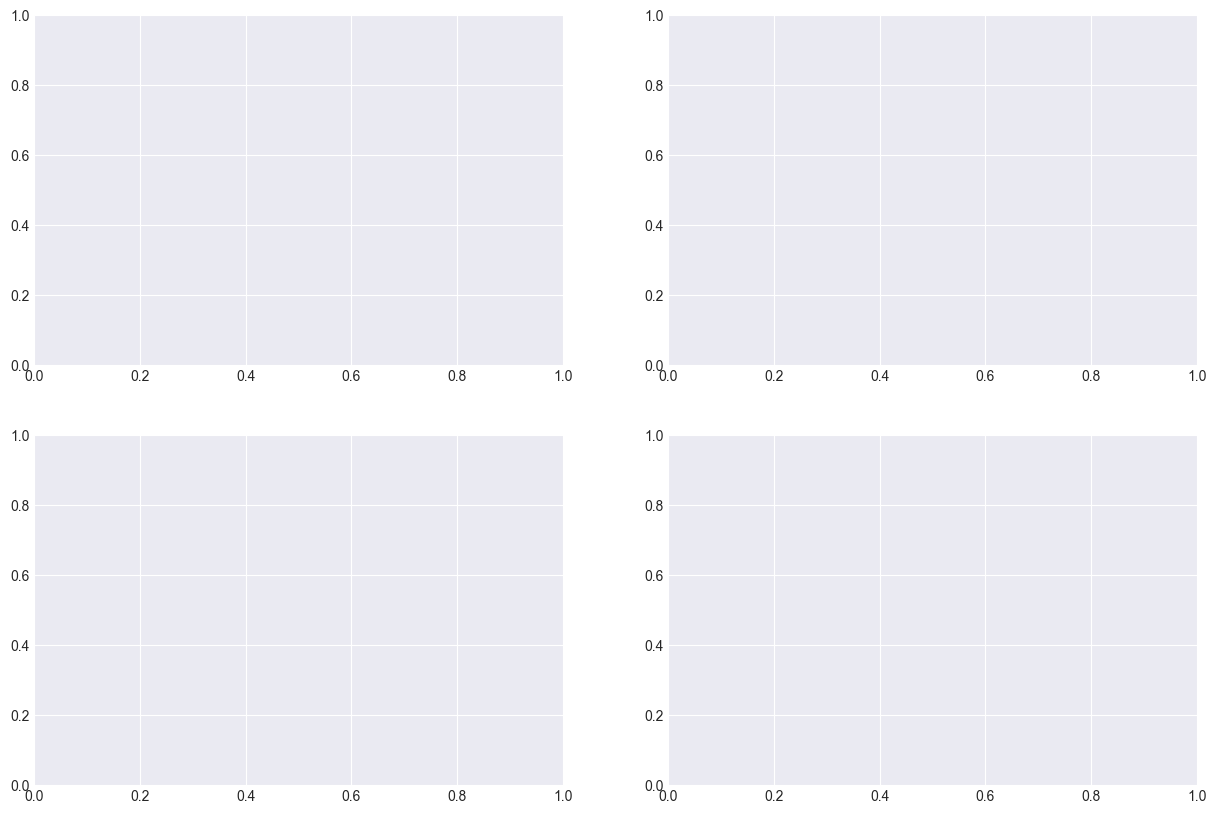

In [11]:
# Plot tracking statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Tracks per frame
tracks_per_frame = result.groupby('frame')['track_id'].nunique()
axes[0, 0].plot(tracks_per_frame.index, tracks_per_frame.values)
axes[0, 0].set_xlabel('Frame')
axes[0, 0].set_ylabel('Number of Tracks')
axes[0, 0].set_title('Active Tracks per Frame')
axes[0, 0].grid(True, alpha=0.3)

# 2. Track length distribution
axes[0, 1].hist(track_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(50, color='r', linestyle='--', label='50 frames')
axes[0, 1].set_xlabel('Track Length (frames)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of Track Lengths')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Spatial distribution
axes[1, 0].scatter(result['x1'], result['y1'], alpha=0.1, s=1)
axes[1, 0].set_xlabel('X coordinate')
axes[1, 0].set_ylabel('Y coordinate')
axes[1, 0].set_title('Spatial Distribution of Detections')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3)

# 4. Detection count over time
dets_per_frame = result.groupby('frame').size()
axes[1, 1].plot(dets_per_frame.index, dets_per_frame.values)
axes[1, 1].set_xlabel('Frame')
axes[1, 1].set_ylabel('Number of Detections')
axes[1, 1].set_title('Detections per Frame')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 9: Save Video with Tracks

In [12]:
# The analyze_video with visualize=True already saved the video
# Check output folder for the visualization video

output_video = os.path.join(OUTPUT_FOLDER, 'tracking_visualization.mp4')
if os.path.exists(output_video):
    print(f"✓ Visualization video saved: {output_video}")
    print(f"  File size: {os.path.getsize(output_video) / 1024 / 1024:.1f} MB")
else:
    # If monitor.save_video() exists, call it
    if hasattr(result, 'save_video'):
        result.save_video(output_folder=OUTPUT_FOLDER)
        print(f"✓ Visualization video saved: {output_video}")
    else:
        print("ℹ Video may be in output folder with different name")
        print(f"  Check: {OUTPUT_FOLDER}")

NameError: name 'result' is not defined

## Summary and Recommendations

In [13]:
print("="*80)
print("ANALYSIS COMPLETE - SUMMARY")
print("="*80)

print("\n✓ Configuration Used:")
print(f"  min_area: {config.detection.min_area}")
print(f"  min_solidity: {config.detection.min_solidity}")
if hasattr(config.detection, 'max_area'):
    print(f"  max_area: {config.detection.max_area}")

print("\n✓ Results:")
print(f"  Total tracks: {total_tracks}")
print(f"  Long tracks (>50 frames): {len(long_tracks)}")
print(f"  Short tracks (≤10 frames): {len(short_tracks)}")
print(f"  Short track percentage: {len(short_tracks)/total_tracks*100:.1f}%")

print("\n💡 Recommendations:")

if len(short_tracks) > total_tracks * 0.4:
    print("  ⚠ Too many short tracks (>40%)")
    print("  → Increase min_area to 150-200")
    print("  → Increase min_solidity to 0.75-0.8")
    print("  → Consider using ROI to focus on bee hotel only")
elif len(short_tracks) > total_tracks * 0.2:
    print("  ⚠ Some short tracks (20-40%)")
    print("  → Consider slight increase in min_area (+20-30)")
    print("  → Or use noise filter if available")
else:
    print("  ✓ Track distribution looks good!")
    print("  → Current parameters are working well")

if ROI is None:
    print("\n  💡 Tip: Define ROI to focus on bee hotel region")
    print("     This will significantly reduce false positives")

print("\n✓ Output Files:")
print(f"  Tracking CSV: {output_csv}")
print(f"  Visualization: Check {OUTPUT_FOLDER}")

print("\n" + "="*80)

ANALYSIS COMPLETE - SUMMARY

✓ Configuration Used:


AttributeError: 'Config' object has no attribute 'detection'

## Optional: Fine-tune Further

If you still see too many false positives, go back to Step 5 and adjust:

1. **Increase `min_area`**: 120 → 150 → 200
2. **Increase `min_solidity`**: 0.7 → 0.75 → 0.8
3. **Decrease `max_area`**: 4000 → 3000 → 2500
4. **Define/refine ROI**: Focus on bee hotel only
5. **Enable noise filter**: If you have trained CNN model

Then re-run Steps 6-9 to see the improvement!